In [1]:
import os 
import numpy as np
import pandas as pd
from scipy.stats import zscore

import scanpy as sc 

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ddir = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized" 
!ls -alhtr $ddir/P28NRDR*

-rw-r--r--. 1 f7xiesnm zipursky 122M Apr 16  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240416.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 318M May  6  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240429.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 284M May  8  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240506.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 221M May  9  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240508.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 664M Aug  1  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1_rna_merfish_240729.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 371M Aug  8  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1glut_rna_merfish_240729.h5ad
-rw-r--r--. 1 f7xiesnm zipursky  99M Aug  8  2024 /u/home/f/f7xiesnm/project-zipursky/

In [3]:
ddir2 = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/astro_john/cellchat_from_riki"
!ls $ddir2

28nr_vs_28dr_celladhesion.R	     ECM-Receptor_p28nr_vs_28dr.csv
Cell-Cell_Contact_p28nr_vs_28dr.csv  Secreted_Signaling_p28nr_vs_28dr.csv


In [4]:
f = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/merfish_genes.txt"
genes_mer = np.loadtxt(f, dtype=str)
genes_mer.shape

(500,)

# CellChat data
- forget about `.y` for now

In [5]:
f1 = os.path.join(ddir2, 'ECM-Receptor_p28nr_vs_28dr.csv')
df1 = pd.read_csv(f1, index_col=0)

In [6]:
cond = np.logical_xor(
    df1['source.x'] == 'AST', 
    df1['target.x'] == 'AST', 
)

print(cond.sum())
df1sub = df1[cond]
df1sub

153


,ID (source_target_ligand_receptor),source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,pval.y,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INT,INTastX,INTastY
p28nr vs p28dr,,,,,,,,,,,,,,,,,,,,,
822,L5PT_AST_COL9A3_SDC4,L5PT,AST,Col9a3,Sdc4,0.014269,0.0,COL9A3_SDC4,Col9a3 - Sdc4,COLLAGEN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.845607,L5PT_AST_NA_NA,L5PT_AST,NA_NA
312,L4_AST_THBS3_SDC4,L4,AST,Thbs3,Sdc4,0.014374,0.0,THBS3_SDC4,Thbs3 - Sdc4,THBS,...,NaN,NaN,NaN,NaN,NaN,NaN,1.842410,L4_AST_NA_NA,L4_AST,NA_NA
311,L4_AST_THBS3_CD47,L4,AST,Thbs3,Cd47,0.014636,0.0,THBS3_CD47,Thbs3 - Cd47,THBS,...,NaN,NaN,NaN,NaN,NaN,NaN,1.834582,L4_AST_NA_NA,L4_AST,NA_NA
912,L6b_AST_COL4A2_SDC4,L6b,AST,Col4a2,Sdc4,0.014798,0.0,COL4A2_SDC4,Col4a2 - Sdc4,COLLAGEN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.829789,L6b_AST_NA_NA,L6b_AST,NA_NA
455,L4/L5IT_AST_THBS3_SDC4,L4/L5IT,AST,Thbs3,Sdc4,0.014997,0.0,THBS3_SDC4,Thbs3 - Sdc4,THBS,...,NaN,NaN,NaN,NaN,NaN,NaN,1.823986,L4/L5IT_AST_NA_NA,L4/L5IT_AST,NA_NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,AST_Vlp_LAMA2_SV2C,AST,Vlp,Lama2,Sv2c,0.109434,0.0,LAMA2_SV2C,Lama2 - Sv2c,LAMININ,...,0.0,LAMA2_SV2C,Lama2 - Sv2c,LAMININ,ECM-Receptor,KEGG: mmu04512,0.009659,AST_Vlp_AST_Vlp,AST_Vlp,AST_Vlp
444,L4/L5IT_AST_COL4A1_ITGAV_ITGB8,L4/L5IT,AST,Col4a1,ITGAV_ITGB8,0.026353,0.0,COL4A1_ITGAV_ITGB8,Col4a1 - (Itgav+Itgb8),COLLAGEN,...,0.0,COL4A1_ITGAV_ITGB8,Col4a1 - (Itgav+Itgb8),COLLAGEN,ECM-Receptor,KEGG: mmu04512,0.008668,L4/L5IT_AST_L4/L5IT_AST,L4/L5IT_AST,L4/L5IT_AST
915,L6b_AST_LAMC1_DAG1,L6b,AST,Lamc1,Dag1,0.050946,0.0,LAMC1_DAG1,Lamc1 - Dag1,LAMININ,...,0.0,LAMC1_DAG1,Lamc1 - Dag1,LAMININ,ECM-Receptor,KEGG: mmu04512,0.008327,L6b_AST_L6b_AST,L6b_AST,L6b_AST


In [7]:
mols = np.union1d(df1sub['ligand.x'].unique(), 
                  df1sub['receptor.x'].unique())
mols_mer = np.intersect1d(mols, genes_mer)
len(mols), len(mols_mer), mols_mer

(19, 3, array(['Col6a1', 'Sdc4', 'Sv2c'], dtype=object))

In [8]:
cond2 = np.logical_and(
    df1sub['ligand.x'].isin(mols_mer),
    df1sub['receptor.x'].isin(mols_mer),
)
df1sub2 = df1sub[cond2]
len(df1sub2)

5

In [9]:
print(df1sub2['ligand.x'].unique())
print(df1sub2['receptor.x'].unique())
genes_cellchat = np.unique(np.hstack([df1sub2['ligand.x'], df1sub2['receptor.x']]))
genes_cellchat

['Col6a1']
['Sdc4']


array(['Col6a1', 'Sdc4'], dtype=object)

In [10]:
df1sub2s = df1sub2[df1sub2['source.x']=='AST']
df1sub2t = df1sub2[df1sub2['target.x']=='AST']

In [20]:
summary_s = df1sub2s.groupby(['target.x', 'interaction_name.x']).first()['prob.x'].unstack().fillna(0).sort_index()
summary_t = df1sub2t.groupby(['source.x', 'interaction_name.x']).first()['prob.x'].unstack().fillna(0).sort_index()
# summary_s = summary_s.drop(['L2/3/4', 'L4/L5IT', 'INH'])
# summary_t = summary_t.drop(['L2/3/4', 'L4/L5IT', 'INH'])
summary_s.shape, summary_t.shape

((0, 0), (5, 1))

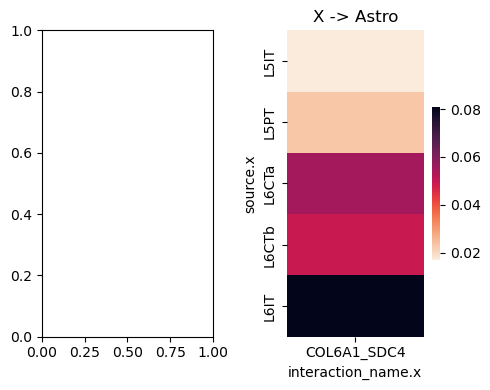

In [21]:
fig, axs = plt.subplots(1,2,figsize=(2.5*2,4))
# ax = axs[0]
# sns.heatmap(summary_s, 
#             cbar_kws={'shrink':0.5, }, cmap='rocket_r', ax=ax)
# ax.set_title('Astro -> X')

ax = axs[1]
sns.heatmap(summary_t, 
            cbar_kws={'shrink':0.5, }, cmap='rocket_r', ax=ax)
ax.set_title('X -> Astro')

fig.tight_layout()
plt.show()

# RNA data

In [22]:
from scipy import sparse

In [23]:
def preprocessing(adata):
    # filter genes
    cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
    adata_sub = adata[:,cond]

    # counts
    x = adata_sub.X
    cov = adata_sub.obs['n_counts'].values

    # CP10k
    xn = (sparse.diags(1/cov).dot(x))*1e4

    # log10(CP10k+1)
    xln = xn.copy()
    xln.data = np.log10(xln.data+1)

    adata_sub.layers['norm'] = xn
    adata_sub.layers['lognorm'] = xln
    
    return adata_sub

In [24]:
def get_hvgs(adata, layer, nbin=20, qth=0.3):
    """
    """
    xn = adata.layers[layer]
    
    # min
    gm = np.ravel(xn.mean(axis=0))

    # var
    tmp = xn.copy()
    tmp.data = np.power(tmp.data, 2)
    gv = np.ravel(tmp.mean(axis=0))-gm**2

    # cut 
    lbl = pd.qcut(gm, nbin, labels=np.arange(nbin))
    gres = pd.DataFrame()
    gres['lbl'] = lbl
    gres['mean'] = gm
    gres['var'] = gv
    gres['ratio']= gv/gm

    # select
    gres_sel = gres.groupby('lbl')['ratio'].nlargest(int(qth*(len(gm)/nbin))) #.reset_index()
    gsel_idx = np.sort(gres_sel.index.get_level_values(1).values)

    assert np.all(gsel_idx != -1)
    
    return adata.var.index.values[gsel_idx]

In [25]:
#
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/cheng21_cell_scrna/organized/P28NR.h5ad'
adata_rna_raw = sc.read(f)
adata_rna_raw

AnnData object with n_obs × n_vars = 23930 × 53801
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass'

In [26]:
adata_rna_raw = preprocessing(adata_rna_raw)
adata_rna_raw

AnnData object with n_obs × n_vars = 23930 × 24498
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass'
    layers: 'norm', 'lognorm'

In [27]:
genes_cellchat_rna = np.intersect1d(adata_rna_raw.var.index.values, genes_cellchat)
genes_cellchat_rna

array(['Col6a1', 'Sdc4'], dtype=object)

# MERFISH data - check these 5 genes

In [28]:
import sys
sys.path.insert(0, '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/myvisctx/analysis_merfish')
import merfish_genesets
import merfish_datasets
import utils_merfish

from scroutines import basicu

In [29]:
def unify_labels(a, b):
    """
    """
    b = b.replace('NA', np.nan)
    
    cat_a = a.cat.categories
    cat_b = b.cat.categories
    
    if len(cat_a)==len(cat_b) and np.all(cat_a==cat_b):
        u = a.fillna(b)
    else:
        cats = np.union1d(cat_a, cat_b)
        a = a.cat.set_categories(cats).copy()
        b = b.cat.set_categories(cats).copy()
        u = a.fillna(b)
        
    return u

In [30]:
%%time
names = [
    'P28NRa_ant', 
    'P28NRa_pos',
    
    'P28NRb_ant', 
    'P28NRb_pos',
    
    'P28DRa_ant', 
    'P28DRa_pos',
    
    'P28DRb_ant', 
    'P28DRb_pos',
]

alldata = {}
for name in names:
    adatasub = sc.read(os.path.join(ddir, f'{name}_l2_v1_240723.h5ad')) 
    adatasub.obs.index = np.char.add(f'{name}', adatasub.obs.index.values)
    alldata[name] = adatasub 
    print(name, len(alldata[name]))
    
genes = adatasub.var.index.values
genes.shape

P28NRa_ant 4875
P28NRa_pos 9816
P28NRb_ant 2984
P28NRb_pos 12329
P28DRa_ant 5986
P28DRa_pos 7733
P28DRb_ant 10244
P28DRb_pos 8207
CPU times: user 989 ms, sys: 1.38 s, total: 2.37 s
Wall time: 10.4 s


(500,)

In [31]:
genesets, df = merfish_genesets.get_all_genesets()
iegs   = genesets['i']
genes_noniegs = np.array([g for g in genes if g not in iegs])
igenes_idx = basicu.get_index_from_array(adatasub.var.index.values, iegs)

In [32]:
mean_total_rna_target = 250
adata_merged = []
for i, name in enumerate(names):
    j = i // 4
    i = i % 4
    
    adatasub = alldata[name].copy()
    adatasub.obs['sample'] = name
    
    norm_cnts = adatasub.layers['norm']
    # mean_per_batch = np.mean(norm_cnts.sum(axis=1))
    mean_per_batch_noniegs = np.mean(adatasub[:,genes_noniegs].layers['norm'].sum(axis=1))
    
    adatasub.layers['jnorm']  = norm_cnts*(mean_total_rna_target/mean_per_batch_noniegs)
    adatasub.layers['ljnorm'] = np.log2(1+adatasub.layers['jnorm'])
    
    adatasub.obs['norm_transcript_count']  = adatasub.layers['norm'].sum(axis=1)
    adatasub.obs['jnorm_transcript_count'] = adatasub.layers['jnorm'].sum(axis=1)
    
    adatasub.obs['depth_show'] = -adatasub.obs['depth'].values - i*1300 # name
    adatasub.obs['width_show'] =  adatasub.obs['width'].values - np.min(adatasub.obs['width'].values) + j*2500   # name
    
    adata_merged.append(adatasub)
    
adata_merged = sc.concat(adata_merged)
adata_merged

AnnData object with n_obs × n_vars = 62174 × 500
    obs: 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'sample', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show'
    obsm: 'X_pca', 'X_xy', 'blanks'
    layers: 'jnorm', 'norm', 'ljnorm'

# Metadata

In [33]:
f = os.path.join(ddir, "P28NRDR_v1_rna_merfish_240729.h5ad")
adata = sc.read(f)

f = os.path.join(ddir, "P28NRDR_v1glut_rna_merfish_240729.h5ad")
adata_exc = sc.read(f, backed='r')
f = os.path.join(ddir, "P28NRDR_v1gaba_rna_merfish_240729.h5ad")
adata_inh = sc.read(f, backed='r')

# organize uClass and uSubclass
a = adata.obs['Class_broad']
b = adata.obs['gated_pred']
adata.obs['uClass'] = unify_labels(a, b)

a = adata_exc.obs['Subclass']
b = adata_exc.obs['gated_pred_subclass']
adata_exc.obs['uSubclass'] = unify_labels(a, b)

a = adata_inh.obs['Subclass']
b = adata_inh.obs['gated_pred_subclass']
adata_inh.obs['uSubclass'] = unify_labels(a, b)

uSubclass = pd.concat([adata_exc.obs['uSubclass'], adata_inh.obs['uSubclass']])
adata.obs = adata.obs.join(uSubclass)
adata.obs['uSubclass'] = adata.obs['uSubclass'].fillna(adata.obs['uClass'])
adata.obs

,batch,n_genes,percent_mito,n_counts,leiden,Doublet Score,cluster,Class_broad,sample,Age,...,leiden_r0.3,umap1,umap2,umap1_self,umap2_self,max_pred,frac_self_neighbors,gated_pred,uClass,uSubclass
AAACCCACAAATGATG-1-P28_1a-P28,P28,3450.0,0.000951,10513.0,3,0.023377,L6CT_B,Excitatory,P28_1a,P28,...,NaN,8.267126,17.154900,NaN,NaN,NA,NaN,NA,Excitatory,L6CT
AAACCCACACCCTAGG-1-P28_1a-P28,P28,4622.0,0.002900,15174.0,2,0.055276,L4_C,Excitatory,P28_1a,P28,...,NaN,11.621952,4.318666,NaN,NaN,NA,NaN,NA,Excitatory,L4
AAACCCAGTTCTCTCG-1-P28_1a-P28,P28,4895.0,0.002141,16814.0,6,0.040816,L2/3_B,Excitatory,P28_1a,P28,...,NaN,12.320524,-0.034990,NaN,NaN,NA,NaN,NA,Excitatory,L2/3
AAACCCATCACTTGTT-1-P28_1a-P28,P28,3751.0,0.000471,12745.0,3,0.012605,L6CT_B,Excitatory,P28_1a,P28,...,NaN,7.646397,16.957756,NaN,NaN,NA,NaN,NA,Excitatory,L6CT
AAACCCATCCTAGCTC-1-P28_1a-P28,P28,4327.0,0.001903,13661.0,1,0.028505,L4_C,Excitatory,P28_1a,P28,...,NaN,15.032149,6.807268,NaN,NaN,NA,NaN,NA,Excitatory,L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P28DRb_pos49001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,4.143420,5.953799,7.271769,5.800007,Oligodendrocytes,0.90,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes
P28DRb_pos49020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,3.795387,11.158264,4.908178,4.226176,OPCs,0.54,OPCs,OPCs,OPCs
P28DRb_pos49040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,2.996678,10.856749,4.674964,4.261509,OPCs,0.71,OPCs,OPCs,OPCs
P28DRb_pos49073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,5.964211,4.365138,7.940835,5.199085,Oligodendrocytes,0.56,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes


In [34]:
adata_merged.obs

,EntityID,fov,volume,center_x,center_y,min_x,min_y,max_x,max_y,anisotropy,...,blended_domains,x2,y2,depth,width,sample,norm_transcript_count,jnorm_transcript_count,depth_show,width_show
P28NRa_ant214236,2595481502624100078,2269,69.309363,12094.184978,6147.414453,12085.551440,6142.846693,12101.562420,6152.728010,1.719774,...,7,1954.735378,1069.544143,1091.081863,7090.367674,P28NRa_ant,627.620831,662.184596,-1091.081863,1090.346632
P28NRa_ant219236,2595481502678100047,2248,111.117518,12048.608568,6237.787188,12044.391522,6233.308738,12051.563595,6241.611470,1.631610,...,7,1858.604816,1101.219928,1076.375370,6992.847297,P28NRa_ant,692.960042,731.122109,-1076.375370,992.826254
P28NRa_ant219246,2595481502678100059,2248,100.689861,12027.438036,6259.726479,12023.429063,6253.828613,12030.937756,6266.051136,1.760410,...,7,1828.121567,1101.763523,1081.084014,6962.725003,P28NRa_ant,218.492703,230.525335,-1081.084014,962.703960
P28NRa_ant219247,2595481502678100060,2248,59.089495,12050.041692,6259.456534,12046.597595,6254.578000,12052.943771,6263.207243,1.468012,...,7,1844.295646,1117.555842,1062.744660,6975.941139,P28NRa_ant,220.005263,232.121194,-1062.744660,975.920096
P28NRa_ant219281,2595481502678100119,2248,380.133967,12026.613099,6259.015436,12019.273876,6252.891351,12031.579141,6266.838696,1.185538,...,7,1828.041033,1100.677421,1082.167779,6962.832515,P28NRa_ant,416.958267,439.920614,-1082.167779,962.811472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P28DRb_pos49020,2027846600588100079,905,432.537334,4908.459448,1264.769815,4903.774890,1260.646940,4913.055581,1268.891176,1.383461,...,5,-2036.610743,373.450997,1049.199752,1020.868049,P28DRb_pos,167.615589,163.697174,-4949.199752,2520.511250
P28DRb_pos49025,2027846600588100088,905,162.775695,4909.892717,1258.938500,4904.879308,1255.350400,4914.077210,1263.662314,1.628380,...,5,-2041.456988,376.996755,1043.199728,1021.109310,P28DRb_pos,104.438196,101.996704,-4943.199728,2520.752511
P28DRb_pos49040,2027846600588100126,905,258.331509,4915.854359,1266.010441,4912.092150,1262.397482,4919.635790,1269.471107,1.655364,...,5,-2041.478115,367.747265,1048.339504,1013.419301,P28DRb_pos,141.291320,137.988298,-4948.339504,2513.062502
P28DRb_pos49073,2027846600588100186,905,199.815348,4900.551323,1272.853467,4895.566390,1266.046817,4905.201039,1279.539903,1.616163,...,5,-2025.356696,372.341805,1059.160472,1026.222292,P28DRb_pos,320.295717,312.808039,-4959.160472,2525.865493


In [35]:
adata_merged = adata_merged[adata[adata.obs['modality']=='merfish'].obs.index]
adata_merged

View of AnnData object with n_obs × n_vars = 43961 × 500
    obs: 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'sample', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show'
    obsm: 'X_pca', 'X_xy', 'blanks'
    layers: 'jnorm', 'norm', 'ljnorm'

In [36]:
genes_cellchat_mer = np.intersect1d(genes, genes_cellchat)
genes_cellchat_mer

array(['Col6a1', 'Sdc4'], dtype=object)

In [37]:
genes_show = genes_cellchat_mer #['Cdh4', 'Negr1', 'Ptprm', 'Plxna1', 'Sema6d']

In [38]:
adata_rna = adata[adata.obs['modality']=='rna']
adata_mer = adata[adata.obs['modality']=='merfish']

In [39]:
adata_rna

View of AnnData object with n_obs × n_vars = 23930 × 361
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self', 'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'uClass', 'uSubclass'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca2', 'X_pca_harmony', 'X_umap', 'X_xy', 'blanks', 'pca', 'umap'
    layers: 'jnorm', 'ljnorm', 'lognorm', 'norm'
    obsp: 'connectivities', 'distances'

In [40]:
adata_mer

View of AnnData object with n_obs × n_vars = 43961 × 361
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self', 'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'uClass', 'uSubclass'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca2', 'X_pca_harmony', 'X_umap', 'X_xy', 'blanks', 'pca', 'umap'
    layers: 'jnorm', 'ljnorm', 'lognorm', 'norm'
    obsp: 'connectivities', 'distances'

In [41]:
sel_adata_raw = adata_rna_raw
sel_adata = adata_rna
sel_col = 'uSubclass'
sel_layer = 'lognorm'
sel_genes = genes_show
sel_data = np.array(sel_adata_raw[:,sel_genes].layers[sel_layer].todense())

dfval = sel_adata.obs[[sel_col]].copy()
dfval[sel_genes] = sel_data
dfval_mean = dfval.groupby(sel_col).mean()
dfval_mean_zscore = zscore(dfval_mean, axis=0)
print(dfval_mean.mean())

Col6a1    0.074665
Sdc4      0.018526
dtype: float32


In [42]:
sel_adata_raw = adata_merged
sel_adata = adata_mer 
sel_col = 'uSubclass'
sel_layer = 'ljnorm'
sel_genes = genes_show
sel_data = np.array(sel_adata_raw[:,sel_genes].layers[sel_layer])

dfval2 = sel_adata.obs[[sel_col]].copy()
dfval2[sel_genes] = sel_data
dfval2_mean = dfval2.groupby(sel_col).mean()
dfval2_mean_zscore = zscore(dfval2_mean, axis=0)
print(dfval2_mean.mean())

Col6a1    0.568897
Sdc4      0.189988
dtype: float64


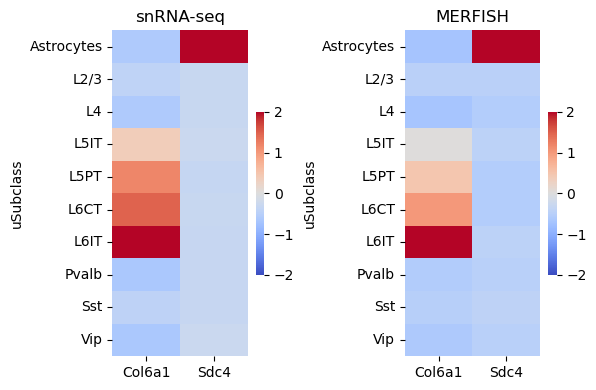

In [43]:
selrows = [
    "Astrocytes", 
    
    "L2/3", "L4", 
    "L5IT", "L5PT", 
    "L6CT", "L6IT",
    "Pvalb", "Sst", "Vip",
    
    # "Endothelial",
    # "OPCs",
    # "Oligodendrocytes",
    # "Microglia",
    # "VLMCs",
]

fig, axs = plt.subplots(1,2,figsize=(3*2,1*4))
ax = axs[0]
ax.set_title('snRNA-seq')
sns.heatmap( dfval_mean_zscore.loc[selrows],
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax = axs[1]
ax.set_title('MERFISH')
sns.heatmap(dfval2_mean_zscore.loc[selrows], 
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()